s1 = 0.5377, w = 0.4372, u = 3.4016


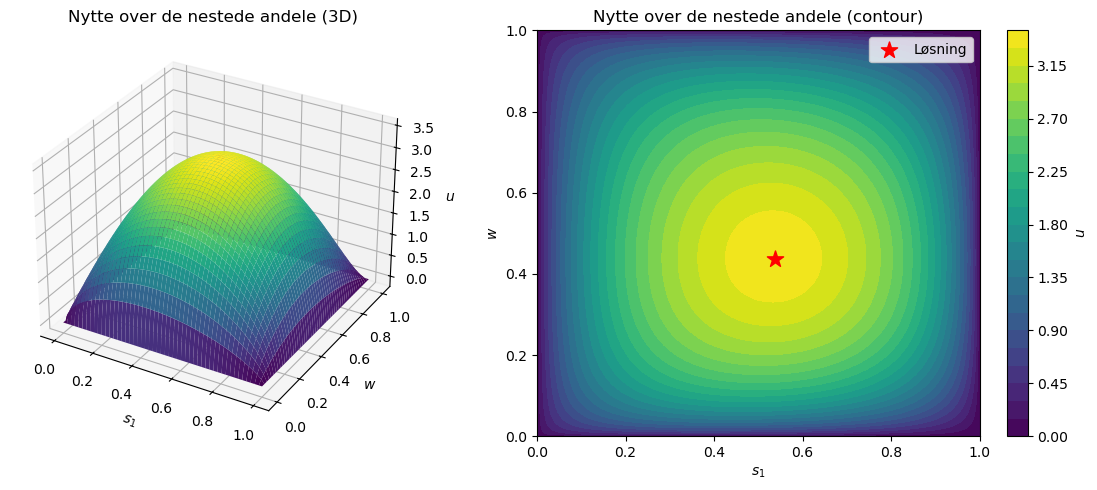

N =    50:  s1 = 0.530612, w = 0.448980, u = 3.400748, evalueringer = 2500
N =   100:  s1 = 0.535354, w = 0.444444, u = 3.401482, evalueringer = 10000
N =   500:  s1 = 0.535070, w = 0.438878, u = 3.401674, evalueringer = 250000
N =  1000:  s1 = 0.535536, w = 0.439439, u = 3.401680, evalueringer = 1000000
s1 = 0.5356, w = 0.4395, u = 3.4017
L-BFGS-B:    s1 = 0.535623, w = 0.439479, u = 3.401680
  funktionsevalueringer: 18
  tid: 1.367 ms
Grid search: s1 = 0.537688, w = 0.437186, u = 3.401601
  funktionsevalueringer: 40000
  tid: 3.277 ms
s1 = 0.5356, w = 0.4395, u = 3.4017


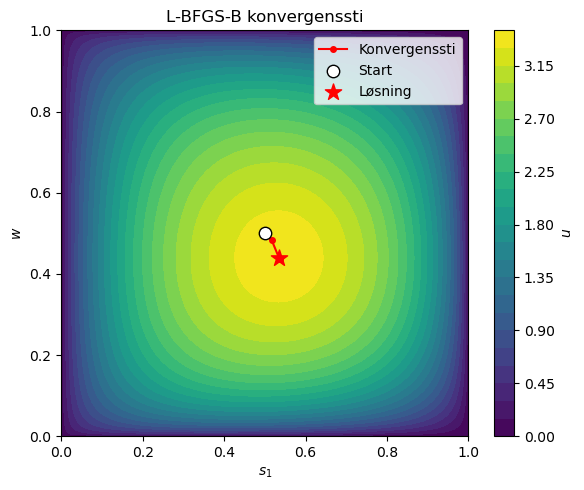

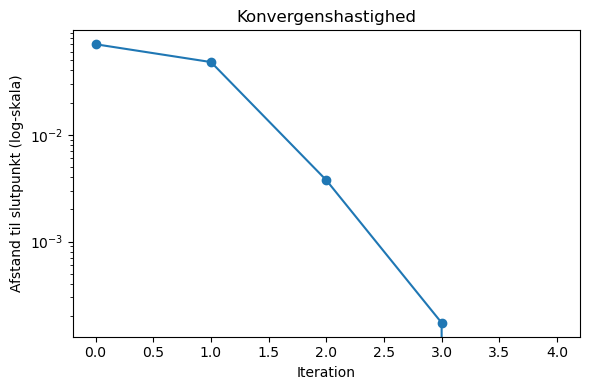

center          : s1 = 0.535623, w = 0.439479, u = 3.401680, iterations = 4, success = True
corner (0,0)    : s1 = 0.535624, w = 0.439478, u = 3.401680, iterations = 7, success = True
corner (0,1)    : s1 = 0.535624, w = 0.439478, u = 3.401680, iterations = 9, success = True
corner (1,0)    : s1 = 0.999991, w = 0.000000, u = 0.000000, iterations = 1, success = True
corner (1,1)    : s1 = 0.999991, w = 1.000000, u = 0.000000, iterations = 1, success = True
extra           : s1 = 0.535624, w = 0.439479, u = 3.401680, iterations = 6, success = True
setting  value              s1          w          u   nfev
ftol     1e-04        0.535607   0.439652   3.401680     15
ftol     1e-08        0.535623   0.439479   3.401680     18
ftol     1e-12        0.535623   0.439479   3.401680     18
ftol     1e-16        0.535623   0.439479   3.401680     18
gtol     1e-02        0.535607   0.439652   3.401680     15
gtol     1e-05        0.535623   0.439479   3.401680     18
gtol     1e-08        0.5356

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from Consumer import ConsumerClass
from Goverment import GovernmentClass

2.1 grid search

In [2]:
c = ConsumerClass()
opt = c.solve_grid(N=200)

s1 = 0.5377, w = 0.4372, u = 3.4016


2.1.2  3D and contour plot

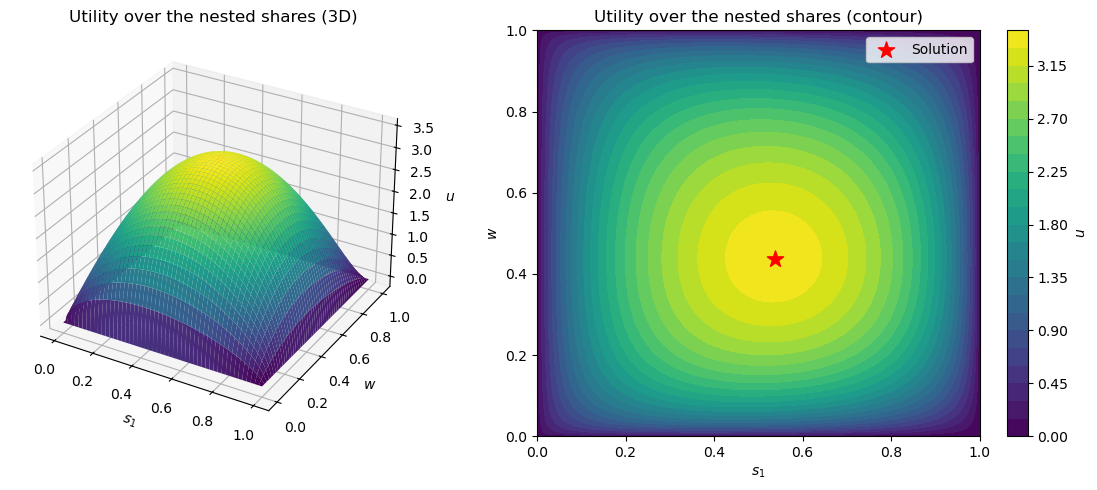

In [3]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1,projection='3d')
ax1.plot_surface(opt.s1_grid, opt.w_grid, opt.u_grid, cmap='viridis')
ax1.scatter([opt.s1], [opt.w], [opt.u], color='red', s=50, label='Solution')
ax1.set_xlabel(r'$s_1$'); ax1.set_ylabel(r'$w$'); ax1.set_zlabel(r'$u$')
ax1.set_title('Utility over the nested shares (3D)')

ax2 = fig.add_subplot(1,2,2)
cont = ax2.contourf(opt.s1_grid, opt.w_grid, opt.u_grid, levels=30, cmap='viridis')
ax2.scatter(opt.s1, opt.w, color='red', marker='*', s=150, label='Solution')
ax2.set_xlabel(r'$s_1$'); ax2.set_ylabel(r'$w$')
ax2.set_title('Utility over the nested shares (contour)')
fig.colorbar(cont, ax=ax2, label=r'$u$')
ax2.legend()

fig.tight_layout()
plt.show()

4.2

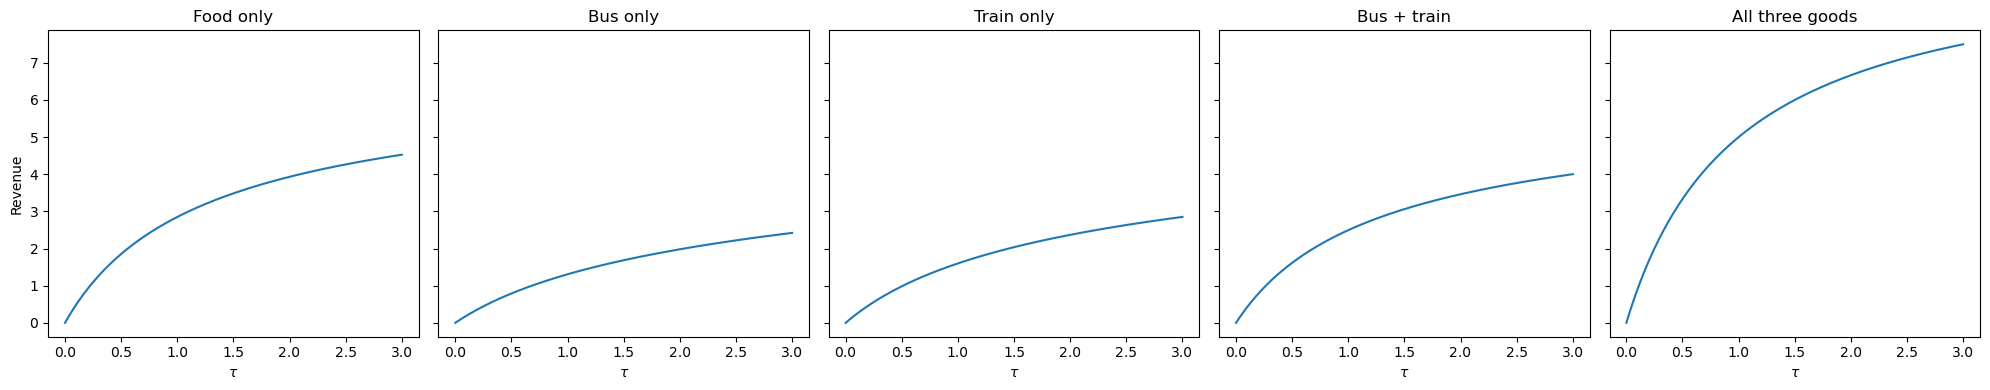

In [4]:
g = GovernmentClass()

tau_vec = np.linspace(0,3,200)

instruments = {
    'Food only':        (1,),
    'Bus only':         (2,),
    'Train only':       (3,),
    'Bus + train':      (2,3),
    'All three goods':  (1,2,3),
}

fig, axes = plt.subplots(1,5,figsize=(20,4),sharey=True)

for ax,(label,goods) in zip(axes,instruments.items()):
    R_vec = np.empty_like(tau_vec)
    for i,tau in enumerate(tau_vec):
        R_vec[i],_ = g.revenue_and_utility(tau,goods=goods)

    ax.plot(tau_vec,R_vec)
    ax.set_xlabel(r'$\tau$')
    ax.set_title(label)

axes[0].set_ylabel('Revenue')
fig.tight_layout()
plt.show()

4.3 Revenue-maximizing

In [5]:
instruments_with_names = {
    'Food only':       (1,),
    'Bus only':        (2,),
    'Train only':      (3,),
    'Bus + train':     (2,3),
    'All three goods': (1,2,3),
}

calibrations = {
    'Complements': GovernmentClass(),
    'Substitutes': GovernmentClass(par={'sigma_B': 3.0}),
}

# Choose the upper limit based on the figures in question 4.2
tau_max = 10.0

for calib_label, g_calib in calibrations.items():

    print(f'\n{calib_label}')

    for label, goods in instruments_with_names.items():

        tau, R = g_calib.max_revenue(
            goods=goods,
            tau_max=tau_max,
            N=2001
        )

        if np.isclose(tau, tau_max):
            print(f'{label:16s}: keeps rising')
        else:
            print(
                f'{label:16s}: top at tau = {tau:.4f}, '
                f'max revenue = {R:.6f}'
            )


Complements
Food only       : keeps rising
Bus only        : keeps rising
Train only      : keeps rising
Bus + train     : keeps rising
All three goods : keeps rising

Substitutes
Food only       : keeps rising
Bus only        : top at tau = 0.8550, max revenue = 0.872144
Train only      : top at tau = 0.5950, max revenue = 0.259039
Bus + train     : keeps rising
All three goods : keeps rising


4.4 Utility vs. revenue 

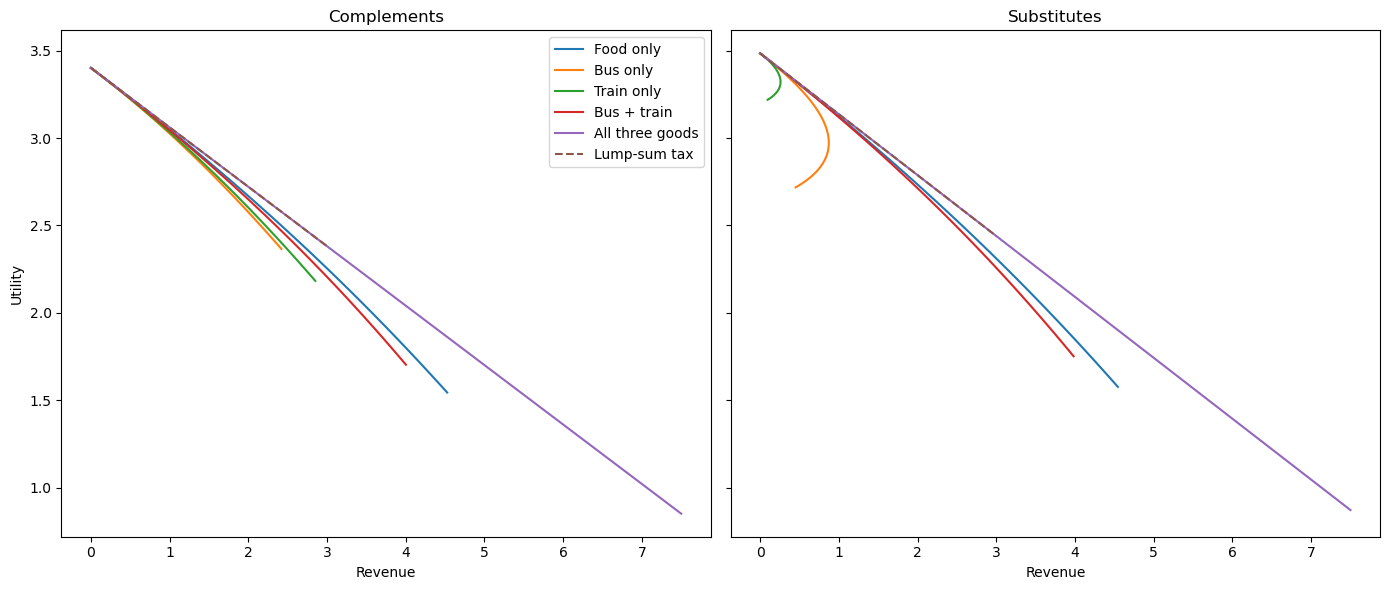

In [6]:
calibrations = {
    'Complements': GovernmentClass(),
    'Substitutes': GovernmentClass(par={'sigma_B':3.0}),
}

tau_vec = np.linspace(0,3,100)
T_vec = np.linspace(0,3,200)

fig, axes = plt.subplots(1,2,figsize=(14,6),sharey=True)

for ax,(calib_label,g_calib) in zip(axes,calibrations.items()):

    for label,goods in instruments_with_names.items():
        R_vec = np.empty_like(tau_vec)
        u_vec = np.empty_like(tau_vec)
        for i,tau in enumerate(tau_vec):
            R_vec[i],u_vec[i] = g_calib.revenue_and_utility(tau,goods=goods)
        ax.plot(R_vec,u_vec,label=label)

    R_vec_T = np.empty_like(T_vec)
    u_vec_T = np.empty_like(T_vec)
    for i,T in enumerate(T_vec):
        R_vec_T[i],u_vec_T[i] = g_calib.revenue_and_utility_lump_sum(T)
    ax.plot(R_vec_T,u_vec_T,label='Lump-sum tax',linestyle='--')

    ax.set_xlabel('Revenue')
    ax.set_title(calib_label)

axes[0].set_ylabel('Utility')
axes[0].legend()
fig.tight_layout()
plt.show()

Exercise 4.3 shows that all the curves continue to rise, with the exception of bus and train (separated), which reaches a maximum. This is because trains and buses are substitutes for one another, whereas food has no substitute in the model.

The lump-sum tax and the tax on all three goods are the cheapest ways to raise a given revenue, as they give the highest utility

In [7]:
import pandas as pd

R_target = 0.20

for calib_label, g_calib in calibrations.items():

    results = []

    # product taxes
    for label, goods in instruments_with_names.items():

        # find the top of the revenue curve
        tau_maxrev, R_max = g_calib.max_revenue(
            goods=goods,
            tau_max=10.0,
            N=2001
        )

        # can this tax raise R = 0.20?
        if R_max >= R_target:

            # search on the increasing part of the revenue curve
            tau = g_calib.find_tax_rate(
                R_target,
                goods=goods,
                bracket=(1e-10, tau_maxrev)
            )

            if np.isnan(tau):
                utility = np.nan
            else:
                R, utility = g_calib.revenue_and_utility(
                    tau,
                    goods=goods
                )

        else:
            tau = np.nan
            utility = np.nan

        results.append({
            'Instrument': label,
            'Tax rate': tau,
            'Utility': utility
        })

    # lump-sum tax
    T = R_target
    R, utility = g_calib.revenue_and_utility_lump_sum(T)

    results.append({
        'Instrument': 'Lump-sum tax',
        'Tax rate': T,
        'Utility': utility
    })

    # make table and rank by utility
    df = pd.DataFrame(results)
    df['Rank'] = df['Utility'].rank(
        ascending=False,
        method='min'
    )

    df = df.sort_values('Rank')

    print(f'\n{calib_label}')
    display(df)


Complements


,Instrument,Tax rate,Utility,Rank
5,Lump-sum tax,0.200000,3.333646,1.0
4,All three goods,0.020408,3.333646,2.0
0,Food only,0.038647,3.333169,3.0
3,Bus + train,0.044787,3.333010,4.0
2,Train only,0.081011,3.332548,5.0
1,Bus only,0.104215,3.332260,6.0



Substitutes


,Instrument,Tax rate,Utility,Rank
5,Lump-sum tax,0.200000,3.415402,1.0
4,All three goods,0.020408,3.415402,2.0
0,Food only,0.038454,3.414919,3.0
3,Bus + train,0.045049,3.414744,4.0
1,Bus only,0.069532,3.412375,5.0
2,Train only,0.236218,3.395521,6.0


The lump-sum tax and the tax on all three goods give the highest utility and are therefore the cheapest ways to raise R=0.20. The ranking changes slightly between the calibrations. In particular, the train tax performs much worse when bus and train are substitutes